In [423]:
# Demo data sampled from normal distribution with np.random.default_rng.normal. Read in real deltas csv to analyze.

In [424]:
import random
import numpy as np
with open("./data/sample_deltas.csv","w") as f:
    f.write("deltas\n")
    rng = np.random.default_rng()
    samples = rng.normal(loc=50000, scale=3, size=1000000)
    for s in [int(sample) for sample in samples]:
        f.write(str(s) + "\n")

In [425]:
import pandas as pd

# DF representing sequence of deltas
deltas = pd.read_csv("./data/sample_deltas.csv")


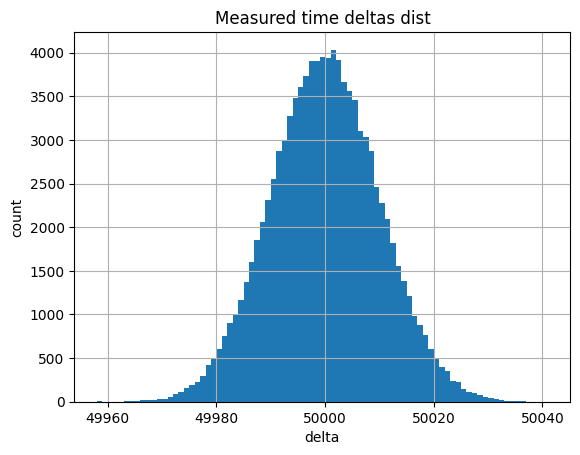

In [431]:
import matplotlib.pyplot as plt
df["deltas"].hist(bins=max(df["deltas"].values) - min(df["deltas"].values))
plt.xlabel("delta")
plt.ylabel("count")
plt.title("Measured time deltas dist")
plt.show()

In [427]:
### Make generated_counts df for probs computation
generated_counts = deltas["deltas"].value_counts().reset_index()
generated_counts.columns = ["value", "count"]
total = len(deltas["deltas"])
generated_counts['probs'] = generated_counts["count"]/total

In [428]:
def prob_d2_failure(counts_df):
    return sum([x**2 for x in counts_df["probs"]])

def actual_d2_failure(samples_df):
    deltas = samples_df["deltas"].values
    matches = (deltas[:-1] == deltas[1:]).sum()
    prop = matches / (len(deltas) - 1)
    return matches, prop


matches, empirical_prob = actual_d2_failure(deltas)
theoretical_prob = prob_d2_failure(generated_counts)


print(f"Measured: {empirical_prob}, Theoretical: {theoretical_prob} ")


Measured: 0.09387509387509388, Theoretical: 0.093672039976 


In [ ]:
from collections import defaultdict

def prob_d3_failure(counts_df):
    # extract probability mass function p(d) from dataframe
    probs = dict(zip(counts_df["value"], counts_df["probs"]))
    # instantiate convolution r[s] = sum (p_a *  p_c for all a + c = s)
    conv = defaultdict(float)
    values = list(probs.keys())
    for a in values:
        for c in values:
            conv[a + c] += probs[a] * probs[c]
    # sum (p_b * r[2b] over all b) to get final expected proportion of delta_3 failures
    total = 0.0
    for b, pb in probs.items():
        total += pb * conv[2 * b]
    return total

def actual_d3_failure(samples_df):
    deltas = samples_df["deltas"].values
    first_diff = np.diff(deltas)
    matches = (first_diff[:-1] == first_diff[1:]).sum()
    prop = matches / (len(deltas) - 2)
    return matches, prop

matches, empirical_prob = actual_d3_failure(deltas)
theoretical_prob = prob_d3_failure(generated_counts)

print(f"Measured: {empirical_prob}, Theoretical: {theoretical_prob} ")


Measured: 0.054109108218216434, Theoretical: 0.05407552524670854 
